# DSA 4060 | Week 1 Practical
## Build and Publish a Popularity Based Movie Recommender

**Student:** Halima Mohammed 



This notebook uses the MovieLens latest-small dataset to inspect user-item ratings, calculate movie popularity, build a minimum-rating popularity recommender and a weighted-rating recommender, test the results, and discuss the strengths and limitations of a non-personalized baseline.

## 1. Import Libraries

In [23]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Define File Paths

In [24]:
# Works when VS Code starts Jupyter in either the project root or notebooks folder.
if Path("data/movies.csv").exists():
    PROJECT_ROOT = Path(".")
elif Path("../data/movies.csv").exists():
    PROJECT_ROOT = Path("..")
else:
    raise FileNotFoundError(
        "Place movies.csv and ratings.csv inside the project's data folder."
    )

DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

MOVIES_FILE = DATA_DIR / "movies.csv"
RATINGS_FILE = DATA_DIR / "ratings.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("Movies file:", MOVIES_FILE.resolve())
print("Ratings file:", RATINGS_FILE.resolve())

Project root: C:\Users\HALIMA MAHDI\Downloads\dsa4060-week1-recommender
Movies file: C:\Users\HALIMA MAHDI\Downloads\dsa4060-week1-recommender\data\movies.csv
Ratings file: C:\Users\HALIMA MAHDI\Downloads\dsa4060-week1-recommender\data\ratings.csv


## 3. Load the CSV Files

In [25]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (9742, 3)
Ratings shape: (100836, 4)


## 4. Preview and Inspect

In [26]:
display(movies.head())
display(ratings.head())

print("Movies information:")
movies.info()

print("\nRatings information:")
ratings.info()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


Movies information:
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB

Ratings information:
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


## 5. Validate the Data

In [27]:
print("Missing values in movies:")
display(movies.isna().sum())

print("Missing values in ratings:")
display(ratings.isna().sum())

print("Duplicate movie rows:", movies.duplicated().sum())
print("Duplicate rating rows:", ratings.duplicated().sum())

print("Rating range:", ratings["rating"].min(), "to", ratings["rating"].max())
print("Unknown movie IDs:",
      (~ratings["movieId"].isin(movies["movieId"])).sum())

Missing values in movies:


movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:


userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Duplicate movie rows: 0
Duplicate rating rows: 0
Rating range: 0.5 to 5.0
Unknown movie IDs: 0


### Interpretation
Review the validation output. Do not remove rows simply because a duplicate count is non-zero; interpret duplicates according to the dataset definition.

## 6. Summarize the Interaction Data

In [28]:
n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_total = movies["movieId"].nunique()
n_interactions = len(ratings)

print("Unique users:", n_users)
print("Movies in movies.csv:", n_movies_total)
print("Movies with at least one rating:", n_movies_rated)
print("Total rating interactions:", n_interactions)

display(ratings["rating"].describe())

Unique users: 610
Movies in movies.csv: 9742
Movies with at least one rating: 9724
Total rating interactions: 100836


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

## 7. Ratings per User and per Movie

In [29]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

print("Ratings per user:")
display(ratings_per_user.describe())

print("Ratings per movie:")
display(ratings_per_movie.describe())

Ratings per user:


count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie:


count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64

## 8. Rating Distribution

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

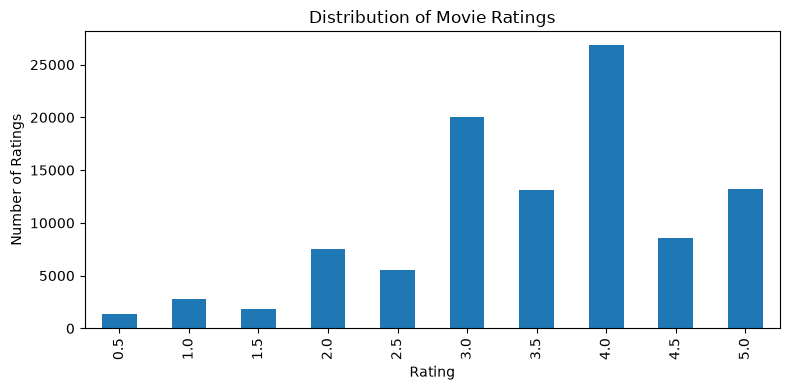

In [30]:
rating_distribution = ratings["rating"].value_counts().sort_index()
display(rating_distribution)

ax = rating_distribution.plot(kind="bar", figsize=(8, 4))
ax.set_title("Distribution of Movie Ratings")
ax.set_xlabel("Rating")
ax.set_ylabel("Number of Ratings")
plt.tight_layout()
plt.show()

### Interpretation
State which rating occurs most often and whether low ratings are relatively rare or common, based only on the chart.

## 9. Interaction Matrix Sparsity

In [31]:
possible_interactions = n_users * n_movies_rated
observed_interactions = n_interactions
sparsity = 1 - (observed_interactions / possible_interactions)

print(f"Possible interactions: {possible_interactions:,}")
print(f"Observed interactions: {observed_interactions:,}")
print(f"Sparsity: {sparsity:.2%}")

Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


### Interpretation
The sparsity percentage represents the proportion of possible user-movie pairs for which no rating is observed.

## 10. Popularity Recommender — Aggregate Ratings

In [32]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(
    movies[["movieId", "title", "genres"]],
    on="movieId",
    how="left",
    validate="one_to_one"
)

display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


## 11. Most Rated Movies

In [33]:
most_rated = (
    movie_stats
    .sort_values(
        ["rating_count", "average_rating"],
        ascending=[False, False]
    )
    .head(10)
)

display(most_rated[["title", "rating_count", "average_rating"]])

,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


## 12. Highest Average Ratings

In [34]:
highest_average = (
    movie_stats
    .sort_values(
        ["average_rating", "rating_count"],
        ascending=[False, False]
    )
    .head(10)
)

display(highest_average[["title", "rating_count", "average_rating"]])

,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


## 13. Minimum-Rating Popularity Baseline

In [35]:
MIN_RATINGS = 50

popular_movies = (
    movie_stats[movie_stats["rating_count"] >= MIN_RATINGS]
    .sort_values(
        ["average_rating", "rating_count"],
        ascending=[False, False]
    )
    .head(10)
)

display(
    popular_movies[
        ["title", "genres", "rating_count", "average_rating"]
    ]
)

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


## 14. Recommendation Function

In [36]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10):
    candidates = stats[stats["rating_count"] >= min_ratings].copy()
    return (
        candidates
        .sort_values(
            ["average_rating", "rating_count"],
            ascending=[False, False]
        )
        .head(top_n)
        [["movieId", "title", "genres", "rating_count", "average_rating"]]
    )

recommendations = recommend_popular_movies(movie_stats, 50, 10)
display(recommendations)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


## 15. Weighted-Rating Baseline

Formula:

**Weighted score = (v / (v + m)) × R + (m / (v + m)) × C**

Where:
- R = movie average rating
- v = number of ratings
- C = overall mean rating
- m = minimum evidence threshold

### 15.1 Select the Threshold

In [37]:
C = ratings["rating"].mean()
m = movie_stats["rating_count"].quantile(0.90)

print(f"Overall mean rating C: {C:.3f}")
print(f"90th percentile rating count m: {m:.1f}")

qualified_count = (movie_stats["rating_count"] >= m).sum()
print("Movies meeting the 90th-percentile threshold:", qualified_count)

Overall mean rating C: 3.502
90th percentile rating count m: 27.0
Movies meeting the 90th-percentile threshold: 976


### 15.2 Calculate Weighted Scores

In [38]:
qualified = movie_stats[movie_stats["rating_count"] >= m].copy()

v = qualified["rating_count"]
R = qualified["average_rating"]

qualified["weighted_score"] = (
    (v / (v + m)) * R +
    (m / (v + m)) * C
)

weighted_recommendations = (
    qualified
    .sort_values(
        ["weighted_score", "rating_count"],
        ascending=[False, False]
    )
    .head(10)
)

display(
    weighted_recommendations[
        ["title", "genres", "rating_count",
         "average_rating", "weighted_score"]
    ]
)

,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.356227
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.191973
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.187927
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.160223
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.151697
461,Schindler's List (1993),Drama|War,220,4.225000,4.145919
257,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,4.140844
897,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,211,4.215640,4.134630
1938,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,4.131285
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.128475


## 16. Compare the Two Lists

In [39]:
comparison = popular_movies[
    ["title", "rating_count", "average_rating"]
].copy()
comparison["method"] = "Minimum 50 ratings"

weighted_view = weighted_recommendations[
    ["title", "rating_count", "average_rating"]
].copy()
weighted_view["method"] = "Weighted score"

display(pd.concat([comparison, weighted_view], ignore_index=True))

common_titles = sorted(
    set(popular_movies["title"]).intersection(
        set(weighted_recommendations["title"])
    )
)

print("Movies appearing in both lists:")
for title in common_titles:
    print("-", title)
print("Number of common movies:", len(common_titles))

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
2,Fight Club (1999),218,4.272936,Minimum 50 ratings
3,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
5,Rear Window (1954),84,4.261905,Minimum 50 ratings
6,"Godfather: Part II, The (1974)",129,4.259690,Minimum 50 ratings
7,"Departed, The (2006)",107,4.252336,Minimum 50 ratings
8,Goodfellas (1990),126,4.250000,Minimum 50 ratings
9,Casablanca (1942),100,4.240000,Minimum 50 ratings


Movies appearing in both lists:
- Fight Club (1999)
- Godfather, The (1972)
- Godfather: Part II, The (1974)
- Shawshank Redemption, The (1994)
Number of common movies: 4


## 17. Top 10 Visualization

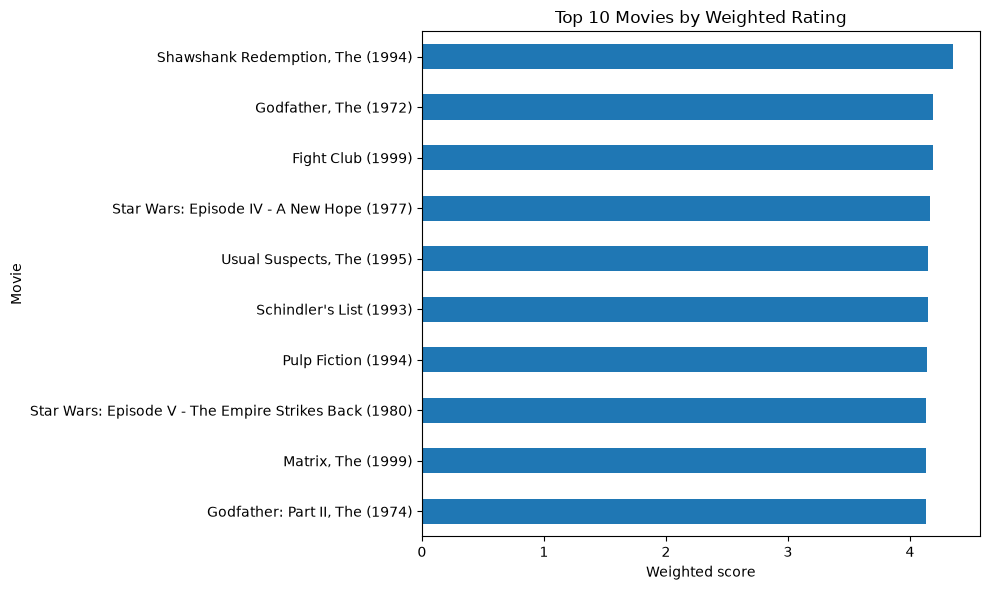

Chart saved to: C:\Users\HALIMA MAHDI\Downloads\dsa4060-week1-recommender\images\top10_recommendations.png


In [40]:
plot_data = weighted_recommendations.sort_values("weighted_score")

ax = plot_data.plot(
    x="title",
    y="weighted_score",
    kind="barh",
    figsize=(10, 6),
    legend=False
)

ax.set_title("Top 10 Movies by Weighted Rating")
ax.set_xlabel("Weighted score")
ax.set_ylabel("Movie")
plt.tight_layout()

chart_path = IMAGES_DIR / "top10_recommendations.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path.resolve())

## 18. Basic Tests

In [41]:
assert len(recommendations) <= 10
assert recommendations["movieId"].is_unique
assert recommendations["rating_count"].ge(50).all()
assert recommendations["average_rating"].between(0.5, 5.0).all()
assert recommendations["title"].notna().all()

assert len(weighted_recommendations) <= 10
assert weighted_recommendations["weighted_score"].notna().all()

print("All checks passed.")

All checks passed.


## 19. Try Different Parameters

In [42]:
print("Top 5 with minimum 20 ratings:")
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5))

print("Top 5 with minimum 100 ratings:")
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

Top 5 with minimum 20 ratings:


,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


Top 5 with minimum 100 ratings:


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


## 20. Optional Genre Filter

In [43]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10):
    mask = stats["genres"].str.contains(genre, case=False, na=False)
    return recommend_popular_movies(stats[mask], min_ratings, top_n)

display(recommend_by_genre(movie_stats, "Comedy", 30, 10))

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


## 21. Key Results

In [44]:
most_rated_movie = most_rated.iloc[0]
minimum_threshold_movie = popular_movies.iloc[0]
weighted_top_movie = weighted_recommendations.iloc[0]

print("Movie with the most ratings:", most_rated_movie["title"])
print("Rating count:", int(most_rated_movie["rating_count"]))
print("Average rating:", round(most_rated_movie["average_rating"], 3))

print("\nTop movie after 50-rating threshold:",
      minimum_threshold_movie["title"])
print("Rating count:", int(minimum_threshold_movie["rating_count"]))
print("Average rating:",
      round(minimum_threshold_movie["average_rating"], 3))

print("\nTop movie using weighted score:",
      weighted_top_movie["title"])
print("Weighted score:",
      round(weighted_top_movie["weighted_score"], 3))

print("\nMovies qualifying under 90th-percentile threshold:",
      qualified_count)

Movie with the most ratings: Forrest Gump (1994)
Rating count: 329
Average rating: 4.164

Top movie after 50-rating threshold: Shawshank Redemption, The (1994)
Rating count: 317
Average rating: 4.429

Top movie using weighted score: Shawshank Redemption, The (1994)
Weighted score: 4.356

Movies qualifying under 90th-percentile threshold: 976


## 22. Findings and Limitations

### Findings
Use the actual notebook output to describe the main dataset observations. Discuss the rating distribution, users, movies, interactions, and sparsity. Compare the minimum-rating and weighted-rating Top 10 lists and identify movies appearing in both.

The minimum-rating popularity baseline provides a simple and transparent recommendation list. It combines average rating with an evidence requirement so that movies with very few ratings do not automatically dominate. The weighted-rating baseline further balances a movie's own average against the overall mean according to its rating count.

### Limitations
The approach is not personalized because every user receives the same ranked list. It can create popularity bias because already-popular movies receive more exposure. New movies with no ratings have a cold-start problem. The approach also does not model changes in preferences over time, diversity, novelty, or the reasons behind individual ratings.

### Possible improvements
Future versions could use genres or textual features for content-based recommendations, user-rating patterns for collaborative filtering, train/test evaluation, diversity and novelty metrics, catalogue coverage, and time-aware modelling.